In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('train.csv')

In [9]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
7308,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(42000, 785)

In [10]:
import matplotlib.pyplot as plt

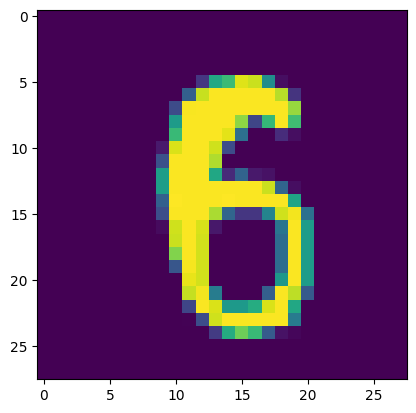

In [12]:
plt.imshow(df.iloc[18386,1:].values.reshape(28,28))

In [13]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [40]:
X_train.shape

(33600, 784)

In [41]:
from sklearn.neighbors import KNeighborsClassifier

In [42]:
knn = KNeighborsClassifier()

In [43]:
knn.fit(X_train,Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [44]:
Y_pred=knn.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)

0.9648809523809524

In [74]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [75]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [95]:
#PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=400)


In [96]:
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.fit_transform(X_test)

In [97]:
X_train_trf.shape

(33600, 400)

In [98]:
knn=KNeighborsClassifier()

In [99]:
knn.fit(X_train_trf,Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [100]:
Y_pred=knn.predict(X_test_trf)

In [101]:
accuracy_score(Y_test,Y_pred)

0.6307142857142857

for i in range(100,785):
    pca=PCA(n_components=i)
    X_train_trf=pca.fit_transform(X_train)
    X_test_trf=pca.fit_transform(X_test)
    knn=KNeighborsClassifier()
    knn.fit(X_train_trf,Y_train)
    Y_pred=knn.predict(X_test_trf)
    accuracy_score(Y_test,Y_pred)

In [103]:
pca=PCA(n_components=2)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.fit_transform(X_test)

In [104]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

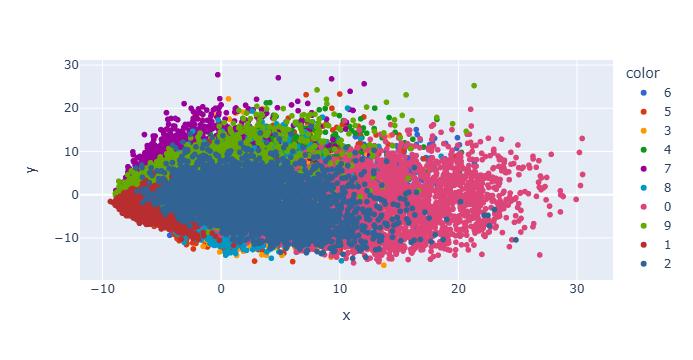

In [106]:
import plotly.express as px
Y_train_trf=Y_train.astype(str)
fig=px.scatter(x=X_train_trf[:,0],
              y=X_train_trf[:,1],
              color=Y_train_trf,
              color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [107]:
pca=PCA(n_components=3)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [108]:
X_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

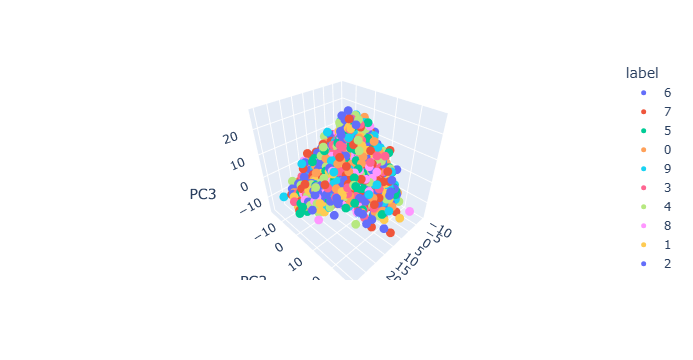

In [121]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)

df = pd.DataFrame(X_train_trf, columns=['PC1','PC2','PC3'])
df['label'] = Y_train.astype(str)

fig = px.scatter_3d(
    df.sample(33600),
    x='PC1',
    y='PC2',
    z='PC3',
    color='label'
)

fig.update_traces(marker=dict(size=5))
fig.show()

In [118]:
pca.explained_variance_
# Eigen Values

array([40.67111198, 29.17023401, 26.74459621])

In [120]:
pca.components_.shape
#Eigen Vectors

(3, 784)

In [122]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

In [123]:
pca=PCA(n_components=None)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [124]:
pca.explained_variance_.shape

(784,)

In [125]:
pca.components_.shape

(784, 784)

In [126]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

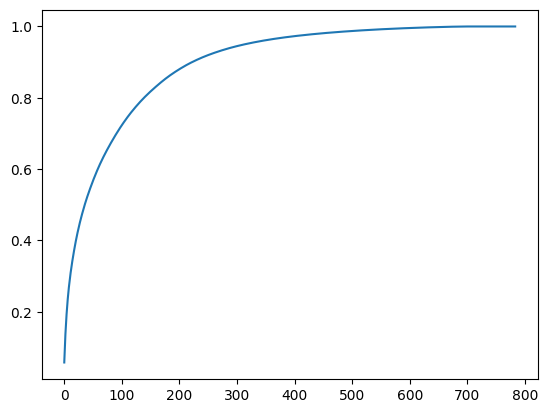

In [129]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))